# Métodos de Monte Carlo

### **O que é o método de Monte Carlo?**

Os métodos de Monte Carlo são uma ampla classe de algoritmos computacionais baseados em amostragem aleatória repetida para obtenção de resultados numéricos. O conceito fundamental é usar a aleatoriedade para resolver problemas determinísticos.

Os métodos de Monte Carlo são usados principalmente em três classes distintas de problemas: otimização, integração numérica e geração de variáveis aleatórias não uniformes, sendo aplicáveis à modelagem de fenômenos com incertezas significativas nos dados de entrada, como, por exemplo, avaliações de risco para usinas nucleares. Os métodos de Monte Carlo são frequentemente implementados por meio de simulações computacionais. Eles podem fornecer soluções aproximadas para problemas complexos demais para análise matemática.

In [ ]:
# Bibliotecas usadas
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns
# %pip install pillow

### **Exemplo 1: Aproximação Normal**

In [ ]:
samples = 10000
n = 12

u = np.random.rand(samples, n)
mean = np.mean(u)
std = np.std(u)
z = (np.sum(u, axis=1) - n * mean) / (std * np.sqrt(n))
normal_samples = np.random.normal(0, 1, 100000)

fig, ax = plt.subplots()

def update(frame):

    ax.clear()
    k = frame

    sns.kdeplot(normal_samples, ax=ax, color="red", label="Normal verdadeira")
    sns.histplot(z[:k], ax=ax, stat="density", bins=80, label="Amostras")
    ax.set_title(f"{k} Amostras")
    ax.legend()

frames = np.linspace(50, samples, 50).astype(int)
ani = FuncAnimation(fig, update, frames=frames, interval=80)
ani.save("normal_montecarlo.gif", writer="pillow", fps=8)

<img src="normal_montecarlo.gif"/>

### **Exemplo 2: Aproximação de $\pi$**

Aproximação de pi: 3.1509714285714288


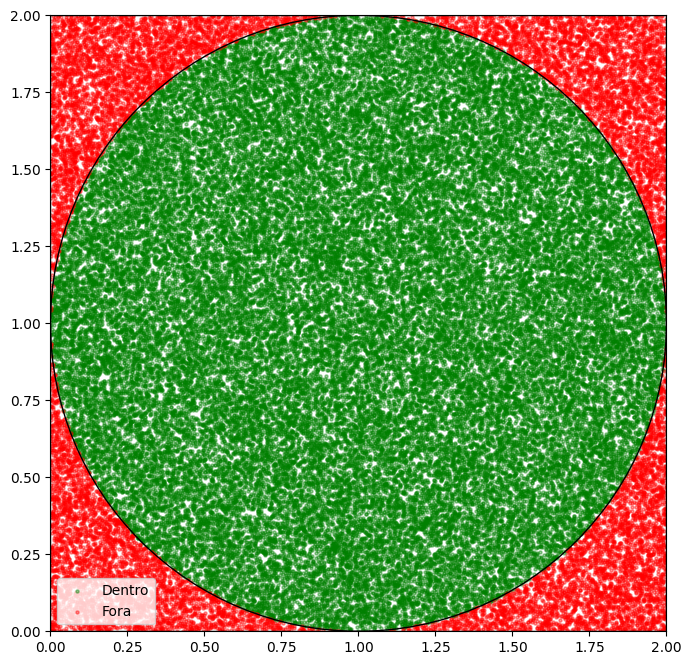

In [ ]:
samples = 70000

# Fazendo as amostras de um quadrado de lado 2
x = np.random.random(samples) * 2
y = np.random.random(samples) * 2
inside = (x - 1)**2 + (y - 1)**2 <= 1  # Condição para estar dentro do círculo
pi_approx = 4 * np.mean(inside)  # Aproximação de Monte Carlo para pi
print("Aproximação de pi:", pi_approx)

# Criando o plot

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(x[inside], y[inside], color="green", alpha=0.4, s=5, label="Dentro")
ax.scatter(x[~inside], y[~inside], color="red", alpha=0.4, s=5, label="Fora")

# Criando o círculo e o quadrado
circle = plt.Circle((1,1), 1, fill=False)
ax.add_patch(circle)
square = plt.Rectangle((0,0), 2, 2, fill=False)
ax.add_patch(square)

ax.set_aspect('equal')
ax.set_xlim(0,2)
ax.set_ylim(0,2)
plt.legend()
plt.show()

### **Exemplo 3: Probabilidade de conclusão de tarefas**

**Descrição do problema**: Você possui um emprego com turno de 9 horas diárias e possui duas tarefas independentes para serem concluídas nesse período. As duas tarefas são independentes e demoram entre 1 a 5 horas e 2 a 6 horas. Qual a probabilidade de você completar ambas tarefas no horário?

Chance de concluir a tempo (estimado): 0.8706
Chance de concluir a tempo (real): 0.875


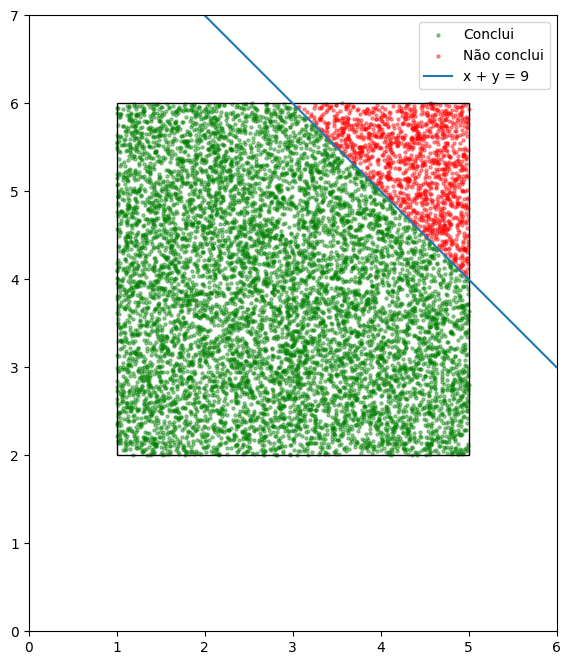

In [ ]:
samples = 10000

# Amostras de um retângulo
task_A = np.random.uniform(1, 5, samples)
task_B = np.random.uniform(2, 6, samples)

inside = task_A + task_B <= 9
print("Chance de concluir a tempo (estimado):", np.mean(inside))
print("Chance de concluir a tempo (real):", 0.875)

# Criando o plot

fig, ax = plt.subplots(figsize=(10,8))

# pontos
ax.scatter(task_A[inside], task_B[inside], color="green", alpha=0.4, s=5, label="Conclui")
ax.scatter(task_A[~inside], task_B[~inside], color="red", alpha=0.4, s=5, label="Não conclui")

# Criando o retângulo e a curva de decisão
square = plt.Rectangle((1,2), 4, 4, fill=False)
ax.add_patch(square)
x = np.linspace(0,6,100)
y = 9 - x
ax.plot(x, y, label="x + y = 9")

ax.set_aspect('equal')
ax.set_xlim(0,6)
ax.set_ylim(0,7)
ax.legend()
plt.show()